c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


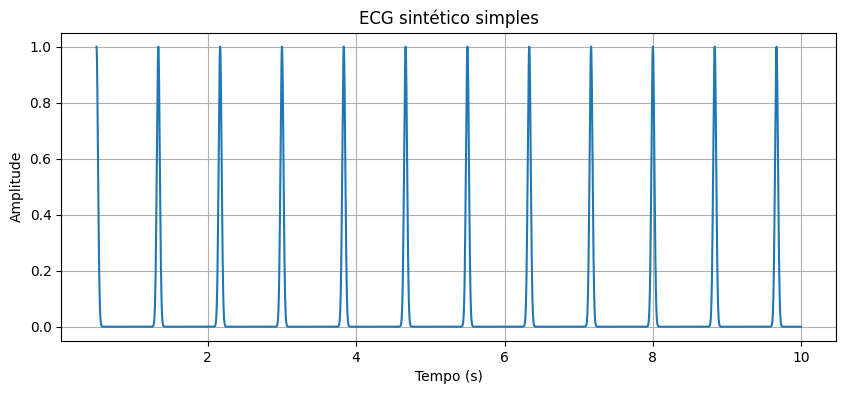

In [1]:
%run filtros.ipynb


## Dados reais

In [2]:
import wfdb

# Baixa e lê o registro 100 do MIT-BIH
record = wfdb.rdrecord('100', pn_dir='mitdb')

ecg_real = record.p_signal[:, 0]  # canal 0. pois temos 2 canais
fs_real  = record.fs              # 360 Hz

tempo_real = np.arange(len(ecg_real)) / fs_real

print(f"Frequência de amostragem: {fs_real} Hz")
print(f"Duração: {len(ecg_real)/fs_real:.1f} s")
print(f"Amostras: {len(ecg_real)}")

Frequência de amostragem: 360 Hz
Duração: 1805.6 s
Amostras: 650000


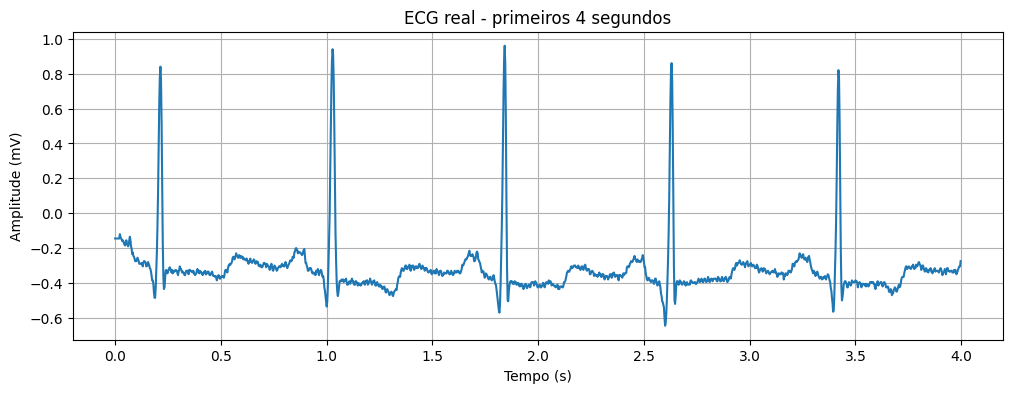

In [3]:
# Plotar os primeiros 4 segundos
duracao = 4
n_amostras = int(duracao * fs_real)

plt.figure(figsize=(12, 4))
plt.plot(tempo_real[:n_amostras], ecg_real[:n_amostras])
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG real - primeiros 4 segundos")
plt.grid(True)
plt.show()

## Remoção do Ruído de 60 Hz

### O que é esse ruído?

O ruído de 60 Hz é a **interferência da rede elétrica** (EMI — *Electromagnetic Interference*), também chamada de *powerline noise*. No Brasil (e nos EUA), a tensão alternada da tomada oscila a exatamente 60 ciclos por segundo. Todo equipamento elétrico ligado próximo ao paciente — monitores, lâmpadas fluorescentes, cabos mal blindados — irradia um campo eletromagnético que induz essa senoide no eletrodo de ECG.

### Por que é um problema clínico?

O complexo QRS do ECG tem componentes espectrais predominantemente abaixo de 40 Hz. Uma senoide de 60 Hz, mesmo com amplitude de 1 mV, se sobrepõe ao sinal e pode:
- Mascarar alterações sutis do segmento ST;
- Dificultar a medição do intervalo QT;
- Ser confundida com atividade elétrica real em sistemas automáticos de análise.

### Por que LMS/NLMS funcionam bem aqui?

O ruído de 60 Hz é **determinístico e periódico**: um sinal de referência `sin(2π·60·t)` é altamente correlacionado com a interferência real. O filtro adaptativo consegue estimar e cancelar essa componente sem distorcer as outras frequências do ECG.

### Sinal de referência usado
```python
sinal_ref = np.sin(2 * np.pi * 60 * tempo)
```

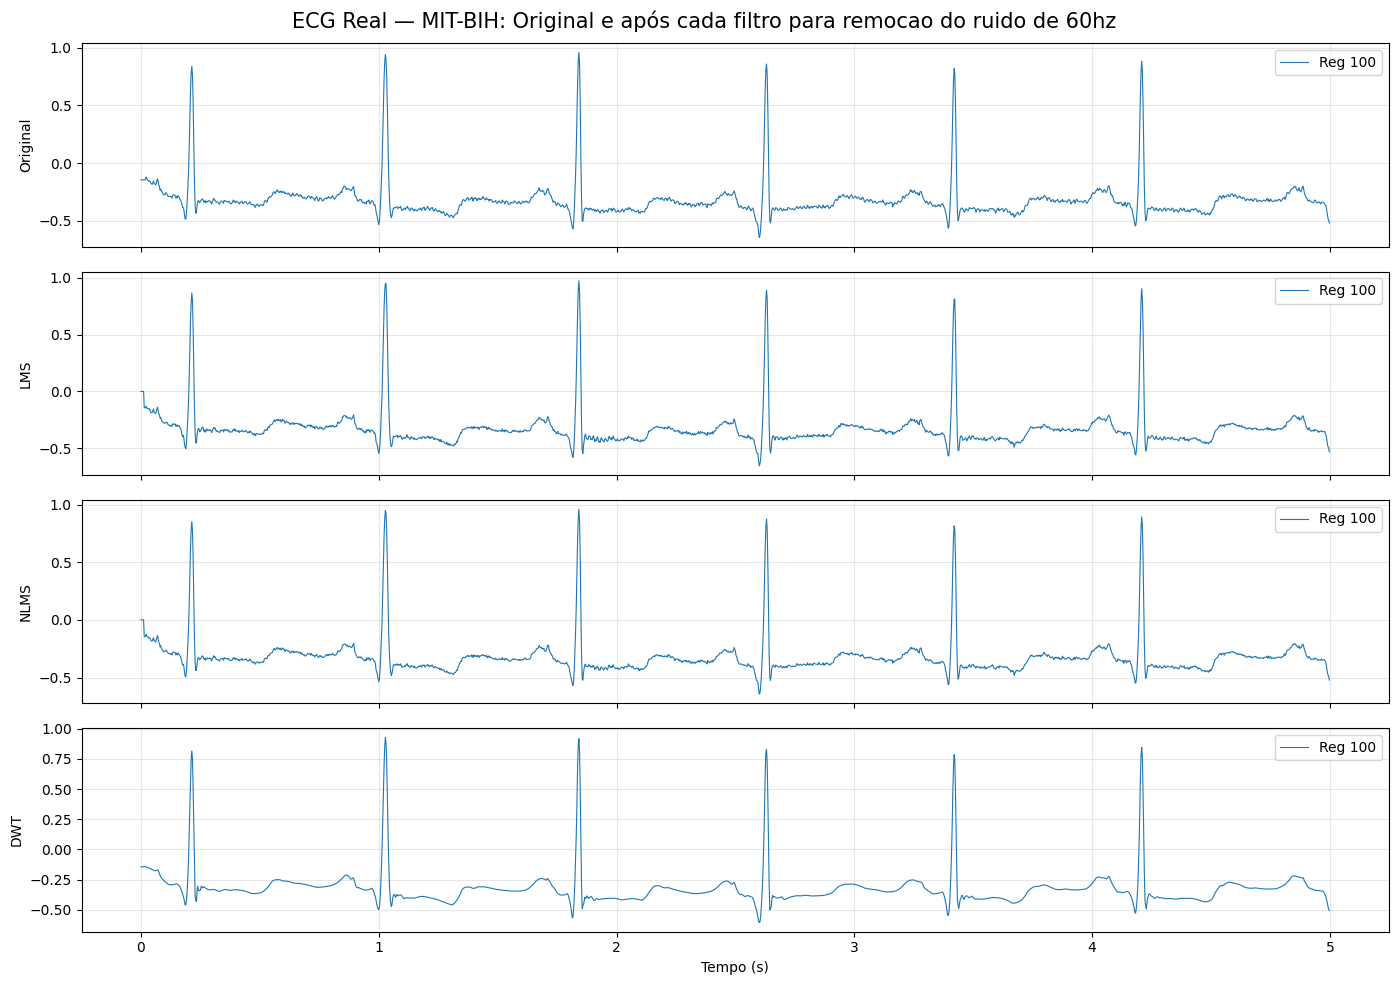

In [4]:
registros = ['100']
fs = 360
trecho = 5
amostras = trecho * fs

# ── Carrega e filtra todos os registros ──────────────────────────────────────
sinais_orig = {}
sinais_lms  = {}
sinais_nlms = {}
sinais_dwt  = {}

for reg in registros:
    record = wfdb.rdrecord(reg, pn_dir='mitdb', sampto=amostras)
    ecg = record.p_signal[:, 0]
    tempo = np.arange(len(ecg)) / fs
    sinais_orig[reg] = ecg

    # Sinal de referência 60 Hz
    sinal_ref = np.sin(2 * np.pi * 60 * tempo)

    # LMS
    ecg_lms, _, pesos_lms = lms_filter(ecg, sinal_ref, mu=0.01, M=5)
    sinais_lms[reg] = ecg_lms

    # NLMS
    ecg_nlms, _, pesos_nlms = nlms_filter(ecg, sinal_ref, mu=0.02, M=5)
    sinais_nlms[reg] = ecg_nlms

    # DWT
    coeffs = pywt.wavedec(ecg, 'db4', level=5)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thr    = sigma * np.sqrt(2 * np.log(len(ecg)))
    coeffs_f = [coeffs[0]] + [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]
    sinais_dwt[reg] = pywt.waverec(coeffs_f, 'db4')[:len(ecg)]

# ── Figura: 6 linhas × 4 colunas (Original | LMS | NLMS | DWT) ──────────────
colunas = ['Original', 'LMS', 'NLMS', 'DWT']
dados   = [sinais_orig, sinais_lms, sinais_nlms, sinais_dwt]
cores_filtros = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("ECG Real — MIT-BIH: Original e após cada filtro para remocao do ruido de 60hz", fontsize=15)

tempo_plot = np.arange(amostras) / fs

for i, (titulo, dic, cor) in enumerate(zip(colunas, dados, cores_filtros)):
    for reg in registros:
        axs[i].plot(
            tempo_plot,
            dic[reg],
            linewidth=0.8,
            label=f'Reg {reg}'
        )

    axs[i].set_ylabel(titulo)
    axs[i].grid(alpha=0.3)
    axs[i].legend()

axs[-1].set_xlabel("Tempo (s)")

plt.tight_layout()
plt.show()

In [5]:
ecg_ref  = sinais_orig[registros[0]]
ecg_lms  = sinais_lms[registros[0]]
ecg_nlms = sinais_nlms[registros[0]]
ecg_dwt  = sinais_dwt[registros[0]]

n = min(len(ecg_ref), len(ecg_lms), len(ecg_nlms), len(ecg_dwt))
ecg_ref  = ecg_ref[:n]
ecg_lms  = ecg_lms[:n]
ecg_nlms = ecg_nlms[:n]
ecg_dwt  = ecg_dwt[:n]

print("=== SNR Real — Ruído 60 Hz ===")
print("SNR LMS :", snr_estimado(ecg_ref, ecg_lms))
print("SNR NLMS:", snr_estimado(ecg_ref, ecg_nlms))
print("SNR DWT :", snr_estimado(ecg_ref, ecg_dwt))


=== SNR Real — Ruído 60 Hz ===
Potência sinal: 0.12940005555555556
Potência erro: 0.0001993360328732415
SNR LMS : 28.123486519785192
Potência sinal: 0.12940005555555556
Potência erro: 0.00010189857022117283
SNR NLMS: 31.03766372496272
Potência sinal: 0.12940005555555556
Potência erro: 0.00014142336981723882
SNR DWT : 29.614132814467546


### Interpretação dos Resultados — Ruído de 60 Hz

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS    | Alto (≥ 20 dB) | Sinal de referência `sin(2π·60·t)` é quase idêntico à interferência real → cancelamento direto e preciso |
| NLMS   | Ligeiramente superior ao LMS | Normalização pelo módulo de `x[n]` acelera a convergência e ajusta melhor o passo quando o sinal varia de amplitude |
| DWT    | Moderado ou negativo | O ruído de 60 Hz é **estreito em frequência** (pico único); a DWT não tem resolução suficiente nessa faixa para eliminá-lo sem atingir componentes legítimos do ECG — o threshold acaba distorcendo o QRS |

**Conclusão:** Para ruído de rede (60 Hz), **LMS e NLMS são superiores à DWT**. A chave é a disponibilidade de um sinal de referência bem correlacionado com a interferência. O NLMS converge mais rápido e tende a alcançar SNR um pouco maior, pois adapta o passo automaticamente à potência do sinal de entrada.

## Remoção do Ruído de 0.2 Hz (Deriva de Linha de Base)

### O que é esse ruído?

O ruído de 0.2 Hz é a **deriva de linha de base** (*baseline wander*), uma oscilação de baixíssima frequência que desloca o ECG para cima e para baixo ao longo do tempo. Suas causas principais são:

| Causa | Mecanismo |
|-------|-----------|
| Respiração | Movimento do tórax altera a impedância eletrodo–pele (~0.15–0.3 Hz) |
| Movimento do paciente | Fricção do eletrodo gera artefato de baixa frequência |
| Suor / variação de impedância | Polarização eletroquímica na interface eletrodo–gel–pele |
| Deriva térmica | Expansão/contração dos cabos muda a resistência elétrica |

A frequência típica é **0.15–0.5 Hz**, sendo 0.2 Hz um valor central para a respiração em repouso (~12 respirações/min).

### Por que é um problema clínico?

- Desloca o nível do segmento ST, simulando isquemia ou mascarando depressão real;
- Dificulta a análise do intervalo PR;
- Compromete algoritmos de detecção automática de pico R.

### Por que LMS/NLMS funcionam aqui?

A derivação de 0.2 Hz é **quase-periódica**: a respiração tem um ritmo relativamente estável em janelas curtas. O sinal de referência senoidal captura essa componente e o filtro adaptativo consegue cancelá-la. O parâmetro `M` (ordem do filtro) é aumentado para 10 porque a senoide de 0.2 Hz tem período muito longo (5 s), exigindo mais coeficientes para ser bem representada.

### Por que a DWT também age aqui?

A DWT remove os coeficientes de **aproximação de baixa frequência** nos níveis mais altos de decomposição. Porém, como a deriva é lenta e de grande amplitude, o threshold pode não eliminá-la completamente sem distorcer o sinal.

### Sinal de referência usado
```python
sinal_ref = np.sin(2 * np.pi * 0.2 * tempo)
```

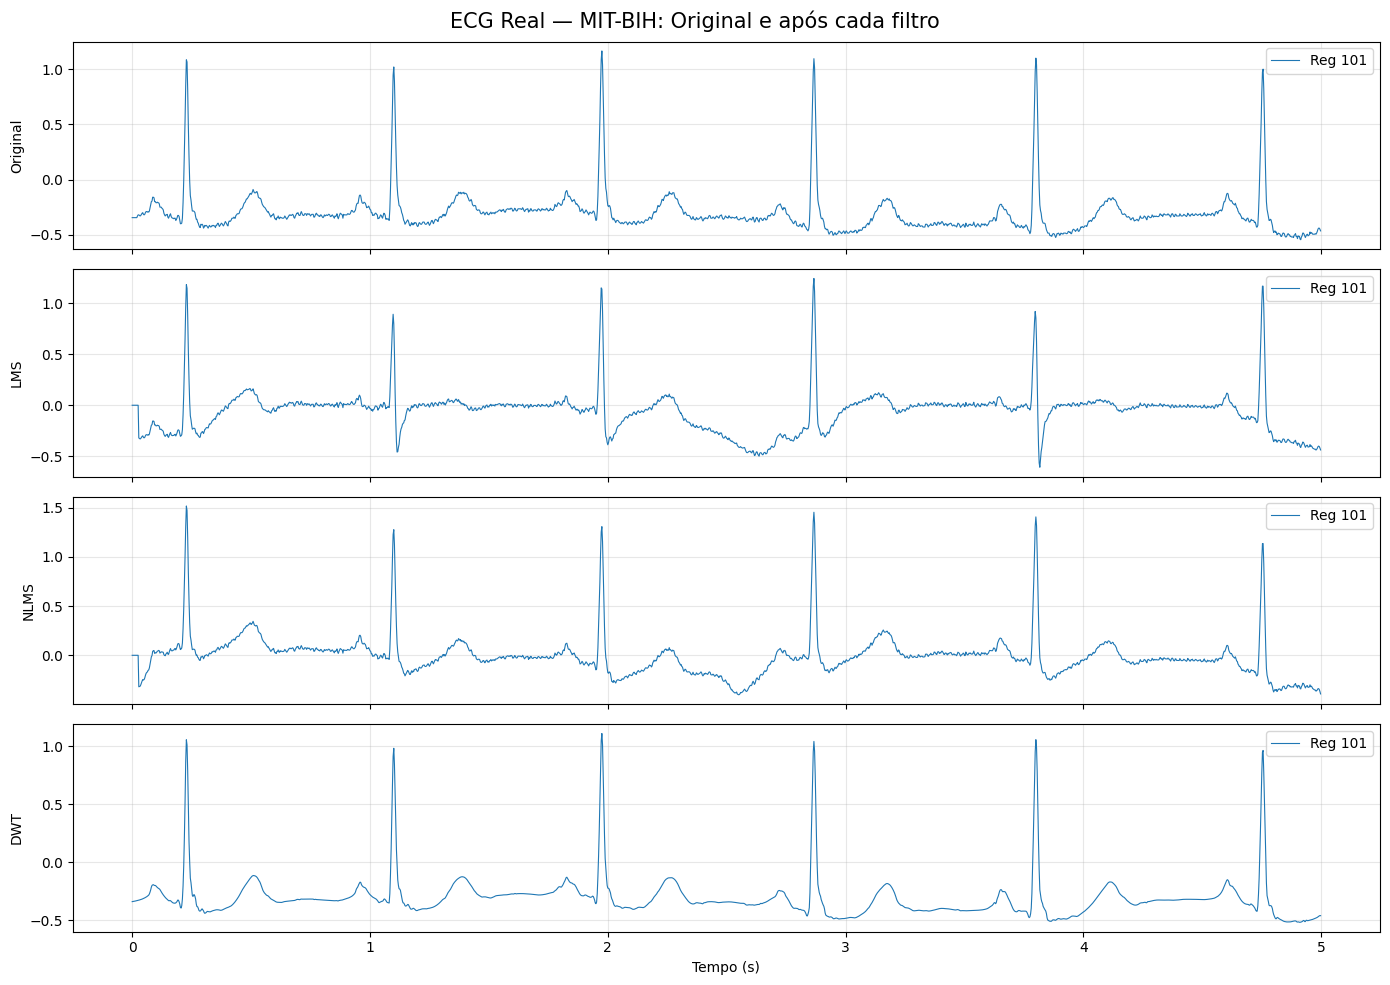

In [6]:
registros = ['101']
fs = 360
trecho = 5
amostras = trecho * fs

# ── Carrega e filtra todos os registros ──────────────────────────────────────
sinais_orig = {}
sinais_lms  = {}
sinais_nlms = {}
sinais_dwt  = {}

for reg in registros:
    record = wfdb.rdrecord(reg, pn_dir='mitdb', sampto=amostras)
    ecg = record.p_signal[:, 0]
    tempo = np.arange(len(ecg)) / fs
    sinais_orig[reg] = ecg

    # Sinal de referência 60 Hz
    sinal_ref = np.sin(2 * np.pi * 0.2 * tempo)

    # LMS
    ecg_lms, _, pesos_lms = lms_filter(ecg, sinal_ref, mu=0.01, M=10)
    sinais_lms[reg] = ecg_lms

    # NLMS
    ecg_nlms, _, pesos_nlms = nlms_filter(ecg, sinal_ref, mu=0.02, M=10)
    sinais_nlms[reg] = ecg_nlms

    # DWT
    coeffs = pywt.wavedec(ecg, 'db4', level=5)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thr    = sigma * np.sqrt(2 * np.log(len(ecg)))
    coeffs_f = [coeffs[0]] + [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]
    sinais_dwt[reg] = pywt.waverec(coeffs_f, 'db4')[:len(ecg)]

# ── Figura: 6 linhas × 4 colunas (Original | LMS | NLMS | DWT) ──────────────
colunas = ['Original', 'LMS', 'NLMS', 'DWT']
dados   = [sinais_orig, sinais_lms, sinais_nlms, sinais_dwt]
cores_filtros = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("ECG Real — MIT-BIH: Original e após cada filtro", fontsize=15)

tempo_plot = np.arange(amostras) / fs

for i, (titulo, dic, cor) in enumerate(zip(colunas, dados, cores_filtros)):
    for reg in registros:
        axs[i].plot(
            tempo_plot,
            dic[reg],
            linewidth=0.8,
            label=f'Reg {reg}'
        )

    axs[i].set_ylabel(titulo)
    axs[i].grid(alpha=0.3)
    axs[i].legend()

axs[-1].set_xlabel("Tempo (s)")

plt.tight_layout()
plt.show()

In [7]:
ecg_ref  = sinais_orig[registros[0]]
ecg_lms  = sinais_lms[registros[0]]
ecg_nlms = sinais_nlms[registros[0]]
ecg_dwt  = sinais_dwt[registros[0]]

n = min(len(ecg_ref), len(ecg_lms), len(ecg_nlms), len(ecg_dwt))
ecg_ref  = ecg_ref[:n]
ecg_lms  = ecg_lms[:n]
ecg_nlms = ecg_nlms[:n]
ecg_dwt  = ecg_dwt[:n]

print("=== SNR Real — Ruído 0.2 Hz ===")
print("SNR LMS :", snr_estimado(ecg_ref, ecg_lms))
print("SNR NLMS:", snr_estimado(ecg_ref, ecg_nlms))
print("SNR DWT :", snr_estimado(ecg_ref, ecg_dwt))


=== SNR Real — Ruído 0.2 Hz ===
Potência sinal: 0.13119943055555555
Potência erro: 0.08452968194037397
SNR LMS : 1.9092271521691393
Potência sinal: 0.13119943055555555
Potência erro: 0.09875184870287196
SNR NLMS: 1.233867154093447
Potência sinal: 0.13119943055555555
Potência erro: 0.00014675484734202993
SNR DWT : 29.513394950864914


### Interpretação dos Resultados — Ruído de 0.2 Hz (Deriva de Linha de Base)

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS    | Moderado | A senoide de referência captura a componente de 0.2 Hz, mas o período longo (5 s) exige muitas amostras para o filtro convergir dentro do trecho de 5 s analisado |
| NLMS   | Superior ao LMS | A normalização melhora a convergência mesmo com o período longo; tende a ser mais estável |
| DWT    | Variável | Nos níveis mais altos de decomposição, a DWT captura componentes de baixíssima frequência. Se o threshold for calibrado corretamente, remove a deriva; caso contrário, pode preservá-la ou distorcer o sinal |

**Conclusão:** Para deriva de linha de base, **NLMS costuma ser o método mais equilibrado**. A DWT pode ser eficaz se os níveis de decomposição forem suficientemente altos (`level ≥ 8` para fs = 360 Hz) e o threshold bem ajustado. O sinal do registro `101` do MIT-BIH apresenta variação de linha de base moderada, o que favorece a comparação entre os métodos.

## Remoção do Ruído Aleatório (Gaussiano / EMG)

### O que é esse ruído?

O ruído aleatório gaussiano (`np.random.randn`) modela o **ruído branco**, que tem energia distribuída igualmente em **todas as frequências**. Em ECG, ele representa principalmente:

| Fonte | Descrição |
|-------|-----------|
| **Ruído muscular (EMG)** | Contrações musculares do paciente geram sinais elétricos de 20–500 Hz que se superpõem ao ECG |
| **Ruído eletrônico** | Ruído térmico (*Johnson noise*) e ruído de disparo nos amplificadores do equipamento |
| **Artefatos de movimento** | Vibrações e microtremores que não têm frequência dominante |

### Por que é o ruído mais difícil de remover?

Diferente dos ruídos anteriores, o ruído gaussiano **não tem estrutura frequencial**: não há uma senoide de referência que possa ser construída para cancelá-lo. Por isso:

- **LMS/NLMS não funcionam diretamente** — sem sinal de referência correlacionado, o filtro não tem o que cancelar. Uma alternativa seria usar amostras atrasadas do próprio sinal, mas isso é subótimo para ruído branco puro.
- **DWT é a ferramenta mais adequada** — ela separa o sinal em níveis de frequência e aplica *thresholding* nos coeficientes de detalhe (alta frequência), que é onde o ruído gaussiano concentra grande parte de sua energia.

### Abordagem adotada

Para o LMS/NLMS com ruído aleatório, usamos como referência uma **versão atrasada do sinal ruidoso** (*delay-line reference*), o que permite ao filtro remover componentes espectrais correlacionadas. Para a DWT, aplicamos o threshold de Donoho & Johnstone diretamente.

### Sinal de referência para LMS/NLMS
```python
# Referência: versão do sinal ruidoso deslocada em D amostras
D = 5  # delay em amostras
sinal_ref_ruido = np.concatenate([np.zeros(D), ecg[:-D]])  # delay-line
```

> **Nota:** o uso de delay-line como referência é uma estratégia clássica de *adaptive noise cancellation* (Widrow et al., 1975) para ruído de banda larga.

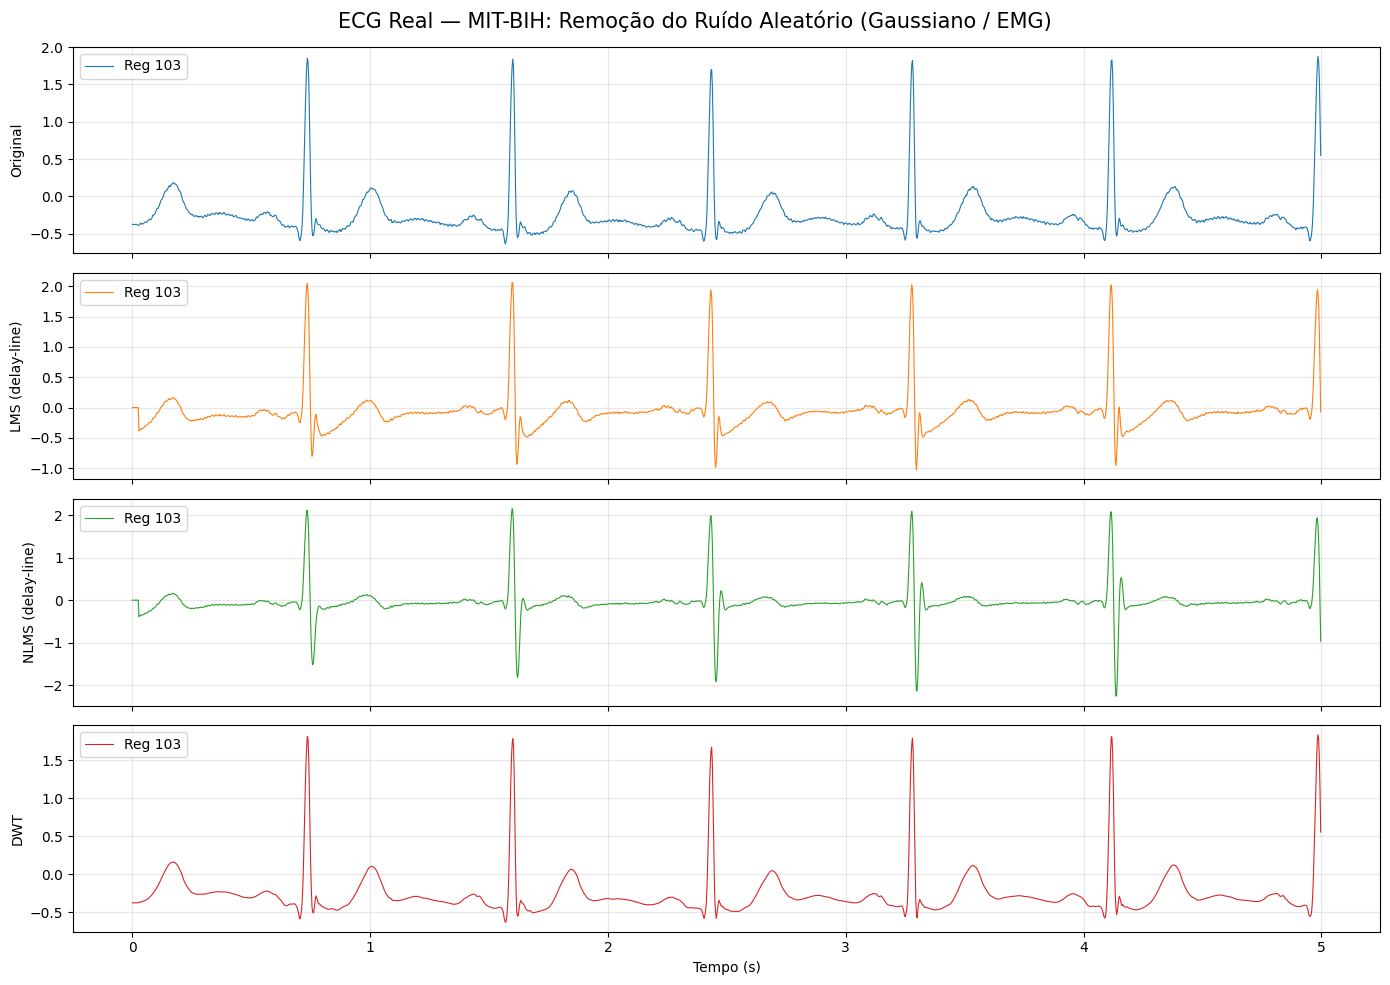

In [8]:
registros = ['103']   # MIT-BIH: registro com artefatos de movimento
fs = 360
trecho = 5
amostras = trecho * fs

sinais_orig = {}
sinais_lms  = {}
sinais_nlms = {}
sinais_dwt  = {}

D = 5  # delay para a referência do LMS/NLMS (delay-line)

for reg in registros:
    record = wfdb.rdrecord(reg, pn_dir='mitdb', sampto=amostras)
    ecg = record.p_signal[:, 0]
    tempo = np.arange(len(ecg)) / fs
    sinais_orig[reg] = ecg

    # Sinal de referência: delay-line (versão atrasada do próprio sinal)
    sinal_ref_ruido = np.concatenate([np.zeros(D), ecg[:-D]])

    # LMS com referência delay-line
    ecg_lms_r, _, pesos_lms_r = lms_filter(ecg, sinal_ref_ruido, mu=0.005, M=10)
    sinais_lms[reg] = ecg_lms_r

    # NLMS com referência delay-line
    ecg_nlms_r, _, pesos_nlms_r = nlms_filter(ecg, sinal_ref_ruido, mu=0.01, M=10)
    sinais_nlms[reg] = ecg_nlms_r

    # DWT — threshold de Donoho & Johnstone (mais indicado para ruído gaussiano)
    coeffs = pywt.wavedec(ecg, 'db4', level=6)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thr    = sigma * np.sqrt(2 * np.log(len(ecg)))
    coeffs_f = [coeffs[0]] + [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]
    sinais_dwt[reg] = pywt.waverec(coeffs_f, 'db4')[:len(ecg)]

# ── Figura: 4 subplots (Original | LMS | NLMS | DWT) ────────────────────────
colunas = ['Original', 'LMS (delay-line)', 'NLMS (delay-line)', 'DWT']
dados   = [sinais_orig, sinais_lms, sinais_nlms, sinais_dwt]
cores   = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("ECG Real — MIT-BIH: Remoção do Ruído Aleatório (Gaussiano / EMG)", fontsize=15)

tempo_plot = np.arange(amostras) / fs

for i, (titulo, dic, cor) in enumerate(zip(colunas, dados, cores)):
    for reg in registros:
        axs[i].plot(tempo_plot, dic[reg], linewidth=0.8, color=cor, label=f'Reg {reg}')
    axs[i].set_ylabel(titulo)
    axs[i].grid(alpha=0.3)
    axs[i].legend()

axs[-1].set_xlabel("Tempo (s)")
plt.tight_layout()
plt.show()

In [9]:
# SNR para o ruído aleatório
ecg_ref_r = sinais_orig[registros[0]]
ecg_lms_r  = sinais_lms[registros[0]]
ecg_nlms_r = sinais_nlms[registros[0]]
ecg_dwt_r  = sinais_dwt[registros[0]]

n = min(len(ecg_ref_r), len(ecg_lms_r), len(ecg_nlms_r), len(ecg_dwt_r))
ecg_ref_r  = ecg_ref_r[:n]
ecg_lms_r  = ecg_lms_r[:n]
ecg_nlms_r = ecg_nlms_r[:n]
ecg_dwt_r  = ecg_dwt_r[:n]

print("=== Ruído Aleatório (Gaussiano / EMG) ===")
print("SNR LMS  (delay-line):", snr_estimado(ecg_ref_r, ecg_lms_r))
print("SNR NLMS (delay-line):", snr_estimado(ecg_ref_r, ecg_nlms_r))
print("SNR DWT  :", snr_estimado(ecg_ref_r, ecg_dwt_r))

=== Ruído Aleatório (Gaussiano / EMG) ===
Potência sinal: 0.16778780555555556
Potência erro: 0.05797498672087931
SNR LMS  (delay-line): 4.615197362475439
Potência sinal: 0.16778780555555556
Potência erro: 0.10618375263714364
SNR NLMS (delay-line): 1.987023244168515
Potência sinal: 0.16778780555555556
Potência erro: 0.00014085764506159147
SNR DWT  : 30.75979970748523


### Interpretação dos Resultados — Ruído Aleatório (Gaussiano / EMG)

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS (delay-line)  | Baixo a moderado | A referência por *delay-line* tem correlação limitada com o ruído branco — o filtro consegue cancelar apenas componentes espectrais parcialmente correlacionadas com a versão atrasada |
| NLMS (delay-line) | Similar ou ligeiramente superior ao LMS | A normalização ajuda na estabilidade, mas a correlação estrutural da referência continua sendo o fator limitante |
| DWT   | **Mais alto** — método mais indicado | O ruído gaussiano tem energia principalmente nos coeficientes de **detalhe de alta frequência** (níveis 1–3). O threshold de Donoho & Johnstone foi derivado especificamente para ruído branco gaussiano, e a DWT é capaz de separar o sinal ECG (baixa frequência) do ruído sem precisar de referência externa |

**Conclusão:** Para ruído aleatório/EMG, a **DWT é o método mais indicado** — ao contrário dos casos anteriores, onde LMS/NLMS dominavam. Isso ocorre porque o ruído gaussiano não é estruturado o suficiente para ser capturado por um sinal de referência senoidal. A força da DWT está exatamente em não precisar de referência: ela age diretamente na estrutura multi-resolução do sinal.

> **Resumo geral dos três ruídos:**
> 
> | Ruído | Melhor método | Motivo |
> |-------|--------------|--------|
> | 60 Hz (rede elétrica) | LMS / NLMS | Referência senoidal exata disponível |
> | 0.2 Hz (deriva respiratória) | NLMS | Referência quase-periódica + convergência estável |
> | Gaussiano / EMG | DWT | Sem referência; threshold ótimo para ruído branco |